## 3-Layer network min-perturbation viewer
### Created Sept 26



In [2]:
import matplotlib.pyplot as plt
import numpy as np
import utils, torch, pickle, utils, model, copy, warnings
from tqdm import trange, tqdm

%load_ext autoreload
%autoreload 2

file_name = 'Saved Results/theory_3L_sigs0P2'

theory_dict = pickle.load(open(file_name, 'rb'))
OPs = theory_dict['OP']
delw1_list = theory_dict['delw1']; delw2_list = theory_dict['delw2']
delw3_list = theory_dict['delw3']
active_inds_list = theory_dict['active_inds']
a_list = theory_dict['a']
args = theory_dict['args']
vary_values = theory_dict['vary_values']
vary_parameter = theory_dict['vary_parameter']

print(args)
# create an instance of the standard stimulus
standard_stim = utils.GaborStimuli(args, simple_mode=True, verbose=False)

Namespace(BATCH_NAME='BATCH_NAME', N=1000, Nhid=1000, TRIAL_IND=0, cluster=0, f=None, loss='MSE', n_layers=3, n_test_trials=10000, n_train_trials=500, noise_var=0.01, nonlinearity='relu', sig_s=0.2, sig_w=0.6, theta=3.141592653589793)


In [58]:
# fix some key differences between versions
if 'sig_w' in theory_dict.keys():
    vary_values = theory_dict['sig_w']
    vary_parameters = 'sig_w'
    theory_dict['vary_values'] = vary_values
    theory_dict['vary_parameter'] = vary_parameters
    # theory_dict.pop('vary_parameters')
    # theory_dict.pop('sig_w')
    pickle.dump(theory_dict, open(file_name, 'wb'))

In [56]:
theory_dict.keys()
args.N = 1000
args.Nhid = 1000
args.sig_s = 0.4

theory_dict['args'] = args
pickle.dump(theory_dict, open(file_name, 'wb'))

## 1. Plot (`imshow`) DelW matrices. Plot |DelW| and order parameters as functions of the varied parameter.

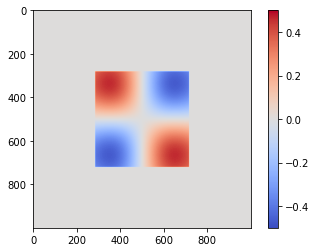

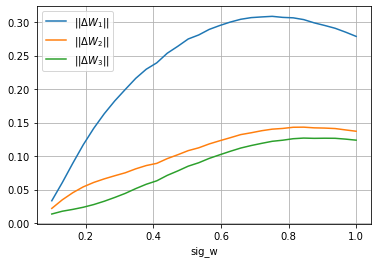

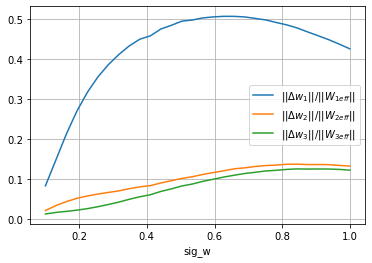

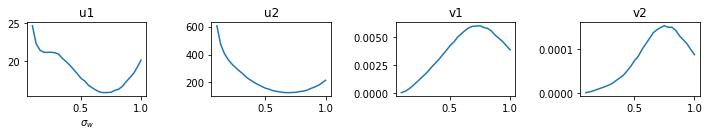

In [2]:
plt.figure()
theory_ind = 23
layer_ind = 2

full_mat = np.zeros((args.N, args.N))
_args = copy.copy(args)
_args.sigw=0.8 # this doesn't matter, since only the difference is shown
_net = model.Model(_args)
W_init = _net.Ws[layer_ind].copy()
t_utils.load_theory_changes(_net, [delw1_list[theory_ind], delw2_list[theory_ind], delw3_list[theory_ind]], active_inds_list[theory_ind])

plt.imshow((_net.Ws[layer_ind] - W_init) * _args.N, cmap='coolwarm', vmin=-0.5, vmax=0.5)
plt.colorbar()
# plt.savefig('figures/raw/3l_theory_delw3.svg')
#%% Compute norm of delWs, plot them; also plot the OPs

delw1_norms = [np.linalg.norm(mat) for mat in delw1_list]
delw2_norms = [np.linalg.norm(mat) for mat in delw2_list]
delw3_norms = [np.linalg.norm(mat) for mat in delw3_list]

plt.figure()
plt.plot(vary_values, delw1_norms, label='$||\Delta W_1||$')
plt.plot(vary_values, delw2_norms, label='$||\Delta W_2||$')
plt.plot(vary_values, delw3_norms, label='$||\Delta W_3||$')
plt.xlabel(vary_parameter); plt.legend(); plt.grid()

normalized_delw1_norms = [np.linalg.norm(delw) / np.sqrt(len(active_inds[1]) / len(active_inds[0])) for delw, active_inds in zip(delw1_list, active_inds_list)]
normalized_delw2_norms = [np.linalg.norm(delw) / np.sqrt(len(active_inds[2]) / len(active_inds[1])) for delw, active_inds in zip(delw2_list, active_inds_list)]
normalized_delw3_norms = [np.linalg.norm(delw) / np.sqrt(len(active_inds[3]) / len(active_inds[2])) for delw, active_inds in zip(delw3_list, active_inds_list)]

plt.figure()
plt.plot(vary_values, normalized_delw1_norms, label='$||\Delta w_1|| / ||W_{1eff}||$')
plt.plot(vary_values, normalized_delw2_norms, label='$||\Delta w_2|| / ||W_{2eff}||$')
plt.plot(vary_values, normalized_delw3_norms, label='$||\Delta w_3|| / ||W_{3eff}||$')
plt.xlabel(vary_parameter)
plt.legend(); plt.grid()

OP_fig = plt.figure(figsize=(10, 2))
OP_fig.add_subplot(141); plt.plot(vary_values, OPs[:, 0]); plt.title('u1'); plt.xlabel('$\sigma_w$')
OP_fig.add_subplot(142); plt.plot(vary_values, OPs[:, 1]); plt.title('u2')
OP_fig.add_subplot(143); plt.plot(vary_values, OPs[:, 2]); plt.title('v1')
OP_fig.add_subplot(144); plt.plot(vary_values, OPs[:, 3]); plt.title('v2')
plt.tight_layout()

In [7]:
data = dataset[6]

def make_w_fig(layer_ind, data, delw1_list, delw2_list, delw3_list, active_inds_list):

    theory_ind = 11
    w_fig = plt.figure()
    w_fig.add_subplot(121); plt.title(f'Theory $\sigma_w=${sig_w_array[theory_ind]:.3f}')
    if layer_ind == 0:
        image = delw1_list[theory_ind]
    elif layer_ind == 1:
        image = delw2_list[theory_ind]
    elif layer_ind == 2:
        image = delw3_list[theory_ind]

    vmax = np.max(np.abs(image * data['args'].N))
    img = plt.imshow(image * data['args'].N, cmap='coolwarm', vmax=vmax, vmin=-vmax)

    w_fig.add_subplot(122)
    active_inds = active_inds_list[theory_ind]
    if layer_ind == 0:
        plt.imshow(utils.recover_matrix(data['delW'][0][-1])[active_inds[1]] * data['args'].N, cmap='coolwarm', vmax=vmax, vmin=-vmax)
    elif layer_ind == 1:
        plt.imshow(utils.recover_matrix(data['delW'][1][-1])[active_inds[2]][:, active_inds[1]] * data['args'].N, cmap='coolwarm', vmax=vmax, vmin=-vmax)
    elif layer_ind == 2:
        plt.imshow(utils.recover_matrix(data['delW'][2][-1])[active_inds[3]][:, active_inds[2]] * data['args'].N, cmap='coolwarm', vmax=vmax, vmin=-vmax)
    plt.title(f'Numerical, $\sigma_w=$ {data["args"].sig_w:.3f}')
    cbar_ax = w_fig.add_axes([0.25, 0.1, 0.5, 0.05])
    w_fig.colorbar(img, cax=cbar_ax, orientation='horizontal')
    plt.tight_layout()

NameError: name 'dataset' is not defined

## Full W comparison

/opt/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:31: RuntimeWarning: divide by zero encountered in double_scalars
/opt/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:32: RuntimeWarning: divide by zero encountered in double_scalars
/opt/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:33: RuntimeWarning: divide by zero encountered in double_scalars


Text(0.5, 1.0, '$||\\Delta _{theory} W_1 - \\Delta _{sgd} W_1 || / ||\\Delta_{sgd} W_1 || $')

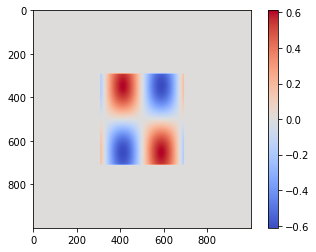

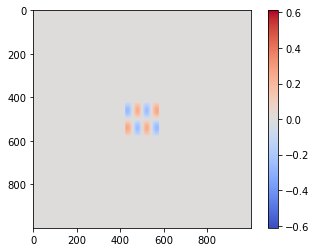

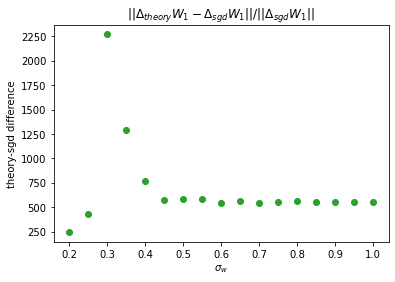

In [8]:
bl_net = model.Model(args)
data_delw = utils.recover_matrix(data['delW'][1][-1])
vmin = np.min(data_delw * data['args'].N)
vmax = np.max(data_delw * data['args'].N)
plt.figure()
plt.imshow(data_delw * data['args'].N, cmap='coolwarm', vmin=vmin, vmax=vmax)
plt.colorbar()
plt.savefig('figures/3l_delw2_N3200_sigw0.1_simulation.svg')

full_theory_delws = r_utils.get_full_delw_mats([delw1_list[0], delw2_list[0], delw3_list[0]], active_inds_list[0], bl_net)
plt.figure()
plt.imshow(full_theory_delws[1] * 1000, cmap='coolwarm', vmin=vmin, vmax=vmax)
plt.colorbar()
plt.savefig('figures/3l_delw2_N3200_sigw0.1_theory.svg')
#%% Measure how well the theory predicts SGD results
delw1_distance = [];delw2_distance = [];delw3_distance = []; sgd_sigws = []

for data in dataset:
    sgd_sigws.append(data['args'].sig_w)
    theory_ind = np.argmin(np.abs(sig_w_array - data['args'].sig_w))
    theory_delw1 = delw1_list[theory_ind]
    theory_delw2 = delw2_list[theory_ind]
    theory_delw3 = delw3_list[theory_ind]
    raw_sgd_delw1 = utils.recover_matrix(data['delW'][0][-1])
    raw_sgd_delw2 = utils.recover_matrix(data['delW'][1][-1])
    raw_sgd_delw3 = utils.recover_matrix(data['delW'][2][-1])
    theory_bounds = active_inds_list[theory_ind]
    sgd_delw1 = raw_sgd_delw1[theory_bounds[0][0]:theory_bounds[0][1], :]
    sgd_delw2 = raw_sgd_delw2[theory_bounds[1][0]:theory_bounds[1][1], theory_bounds[0][0]:theory_bounds[0][1]]
    sgd_delw3 = raw_sgd_delw3[theory_bounds[2][0]:theory_bounds[2][1], theory_bounds[1][0]:theory_bounds[1][1]]
    delw1_distance.append(np.linalg.norm(sgd_delw1 - theory_delw1) / np.linalg.norm(sgd_delw1))
    delw2_distance.append(np.linalg.norm(sgd_delw2 - theory_delw2) / np.linalg.norm(sgd_delw2))
    delw3_distance.append(np.linalg.norm(sgd_delw3 - theory_delw3) / np.linalg.norm(sgd_delw3))

#%%
plt.figure()
plt.scatter(np.sort(sgd_sigws), np.array(delw1_distance)[np.argsort(sgd_sigws)])
plt.scatter(np.sort(sgd_sigws), np.array(delw2_distance)[np.argsort(sgd_sigws)])
plt.scatter(np.sort(sgd_sigws), np.array(delw3_distance)[np.argsort(sgd_sigws)])
plt.xlabel('$\sigma_w$')
plt.ylabel('theory-sgd difference')
plt.title('$||\Delta _{theory} W_1 - \Delta _{sgd} W_1 || / ||\Delta_{sgd} W_1 || $')



## Measure transfer
Usually what is plotted is the normalized transfer. I.e. $$\tilde{\Delta J}(\theta) = \frac{\Delta J(\theta)}{\Delta J (\theta_{tr})}$$

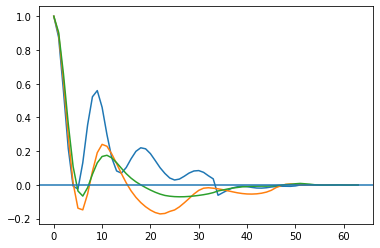

In [9]:
#%% COMPARE TRANSFER ACROSS LAYERS. (1/2) Calculate linear FI for each layer

sig_w_ind = 23
probe_args = copy.copy(args)

probe_args.sig_w = sig_w_array[sig_w_ind]

# create a network
bl_net = model.Model(probe_args)
trained_net = model.Model(probe_args)
t_utils.load_theory_changes(trained_net, [delw1_list[sig_w_ind], delw2_list[sig_w_ind], delw3_list[sig_w_ind]], active_inds_list[sig_w_ind])

# probe_angles = np.linspace(0.5*np.pi, 1.5*np.pi, 64, endpoint=False)
probe_angles = np.linspace(np.pi, 2*np.pi, 64, endpoint=False)

linear_fi_array = np.zeros((3, len(probe_angles)))
baseline_linear_fi_array = np.zeros_like(linear_fi_array)

for i in [1, 2, 3]:

    baseline_linear_fi_array[i-1, :] = r_utils.get_mean_field_fi(bl_net, standard_stim, to_layer=i)


    for j in range(len(probe_angles)):
        probe_args.theta = probe_angles[j]
        probe_stim = train_utils.GaborStimuli(probe_args, simple_mode=True, verbose=False)
        linear_fi_array[i-1, j] = r_utils.get_mean_field_fi(trained_net, probe_stim, to_layer=i)

plt.figure()
for i in range(3):
    plt.plot((linear_fi_array[i] - baseline_linear_fi_array[i]) / (linear_fi_array[i].max() - baseline_linear_fi_array[i][0]))

plt.axhline(0)
# plt.savefig('figures/raw/3layer_specificity_each_layer_0P5pi_1P5pi.svg')
# plt.savefig('figures/raw/3layer_specificity_each_layer_0pi_2pi.svg')

## Measure response properties (required for many cells below)

In [60]:
# Create a list of dictionaries
response_properties = [{'pref':[], 'max':[], 'mean':[], 'mean0':[],'mean_over_stim':[], 'max0':[], 'slope':[],
                        'slope0':[], 'snr':[], 'snr0':[], 'noise':[], 'noise0':[], 'covar':[], 'covar0':[]} for i in range(args.n_layers)]

for i in trange(len(vary_values)):
    args.sig_w = vary_values[i]
    _net = model.Model(args)
    _net2 = model.Model(args)
    utils.load_theory_changes(_net2, [delw1_list[i], delw2_list[i], delw3_list[i]], active_inds_list[i])

    utils.compute_response_properties(_net, _net2, standard_stim, response_properties)


100%|██████████| 30/30 [00:27<00:00,  1.08it/s]


### Histogram of preferred orientation

Text(0.5, 1.0, 'Third layer')

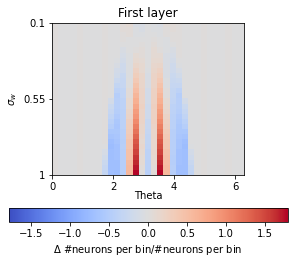

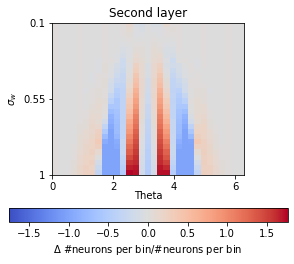

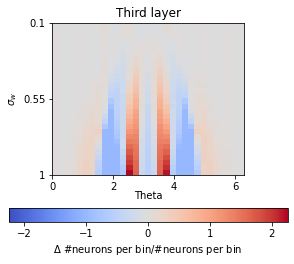

In [61]:
#%% Histogram of preferred orientations

r_utils.preferred_orientation_histogram_figure(response_properties[0], nbins=31); plt.title('First layer')

r_utils.preferred_orientation_histogram_figure(response_properties[1], nbins=31); plt.title('Second layer')

r_utils.preferred_orientation_histogram_figure(response_properties[2], nbins=31); plt.title('Third layer')

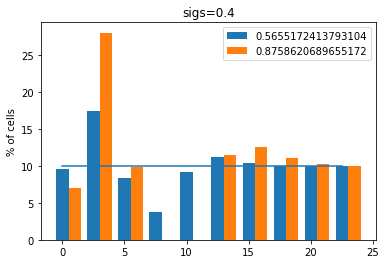

In [75]:
#%% Fig making for preferred orientations
"""CHECK the file name!!!!"""
nbins=10
n_layer=2

plt.figure()
# print(sig_w_array[sig_w_ind]) # ind 16 = 0.5; 23 = 0.8; 29 = 1
sig_w_inds = [15, 25]
for i, sig_w_ind in enumerate(sig_w_inds):
    hist, bin_edges = np.histogram(response_properties[n_layer]['pref'][sig_w_ind] - args.N / 2, bins=np.linspace(-0.1, args.N / 2-.5, nbins+1))


    plt.bar(np.arange(nbins) * 2.5 + 1 * i, hist / hist.sum() * 100, label=str(vary_values[sig_w_ind]), width=1)
    
plt.plot(np.arange(nbins) * 2.5, np.ones(nbins) * 1 / nbins * 100)
plt.ylabel('% of cells')
plt.legend()
plt.title(f'sigs={args.sig_s}')

# plt.ylim(10, 20)
plt.savefig('figures/raw/pref_hist_l3_diff_sigw.svg')

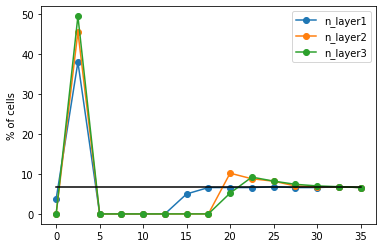

In [51]:
#%% Fig making for preferred orientations
"""CHECK the file name!!!!"""
nbins=15

plt.figure()
# print(sig_w_array[sig_w_ind]) # ind 16 = 0.5; 23 = 0.8; 29 = 1

for n_layer in range(3):
    hist, bin_edges = np.histogram(response_properties[n_layer]['pref'][sig_w_ind] - args.N / 2, bins=np.linspace(-0.1, args.N / 2-.5, nbins+1))


    plt.plot(np.arange(nbins) * 2.5, hist / hist.sum() * 100, marker='o', label='n_layer' + str(n_layer + 1))
plt.plot(np.arange(nbins) * 2.5, np.ones(nbins) * 1 / nbins * 100, color='k')
plt.ylabel('% of cells')
plt.legend()

# plt.ylim(10, 20)
# plt.savefig('figures/raw/pref_hist_l3_diff_sigw.svg')

/opt/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:31: RuntimeWarning: divide by zero encountered in double_scalars
/opt/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:32: RuntimeWarning: divide by zero encountered in double_scalars
/opt/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:33: RuntimeWarning: divide by zero encountered in double_scalars
 30%|███       | 9/30 [00:08<00:19,  1.06it/s]


KeyboardInterrupt: 

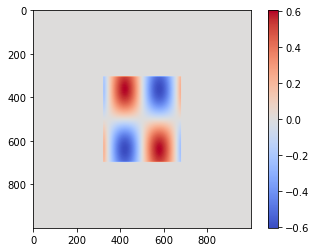

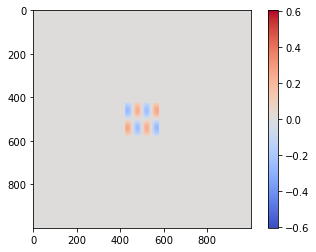

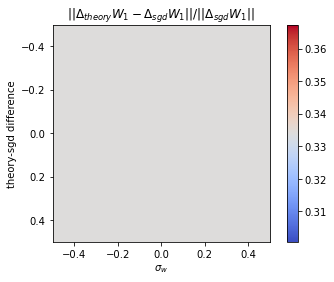

In [6]:



#%%
bounds = active_inds_list[22]
plt.imshow(utils.recover_matrix(data['delW'][2][-1])[bounds[2][0]:bounds[2][1], bounds[1][0]:bounds[1][1]] * data['args'].N, cmap='coolwarm')
plt.colorbar()


#%% slope comparison (before and after)
sig_w_ind = 23
plt.figure()
plt.plot(np.abs(response_properties[0]['slope'][sig_w_ind]) / (6.28 / args.N))
plt.plot(np.abs(response_properties[0]['slope0'][sig_w_ind]) / (6.28 / args.N))
plt.title(f'sigw={sig_w_array[sig_w_ind]}')
# plt.savefig('figures/raw/3layer_l1_slope.svg')

plt.figure()
plt.plot(np.abs(response_properties[1]['slope'][sig_w_ind]) / (6.28 / args.N))
plt.plot(np.abs(response_properties[1]['slope0'][sig_w_ind]) / (6.28 / args.N))
# plt.savefig('figures/raw/3layer_l2_slope.svg')

plt.figure()
plt.plot(np.abs(response_properties[2]['slope'][sig_w_ind]) / (6.28 / args.N))
plt.plot(np.abs(response_properties[2]['slope0'][sig_w_ind]) / (6.28 / args.N))
# plt.savefig('figures/raw/3layer_l3_slope.svg')

# plt.figure()
# plt.scatter(np.abs(response_properties[0]['slope'][sig_w_ind]) / (6.28 / args.N), np.abs(response_properties[0]['slope0'][sig_w_ind]) / (6.28 / args.N), )
# plt.plot([0, 2], [0, 2])
#%% snr comparison (before and after)
sig_w_ind = 13
print(sig_w_array[sig_w_ind])
plt.figure()
plt.plot(np.abs(response_properties[0]['snr'][sig_w_ind]))
plt.plot(np.abs(response_properties[0]['snr0'][sig_w_ind]))
plt.savefig('figures/raw/3layer_l1_snr_sigw0p5_sigs0p2.svg')

plt.figure()
plt.plot(np.abs(response_properties[1]['snr'][sig_w_ind]))
plt.plot(np.abs(response_properties[1]['snr0'][sig_w_ind]))
plt.savefig('figures/raw/3layer_l2_snr_sigw0p5_sigs0p2.svg')

plt.figure()
plt.plot(np.abs(response_properties[2]['snr'][sig_w_ind]))
plt.plot(np.abs(response_properties[2]['snr0'][sig_w_ind]))
plt.savefig('figures/raw/3layer_l3_snr_sigw0p5_sigs0p2.svg')
#%% Max firing rate

r_utils.max_firing_fig(response_properties[0]); plt.title('First layer')
r_utils.max_firing_fig(response_properties[1]); plt.title('Second layer')
r_utils.max_firing_fig(response_properties[2]); plt.title('Third layer')

#%% Mean firing rate

r_utils.mean_firing_fig(response_properties[0]); plt.title('First layer')
r_utils.mean_firing_fig(response_properties[1]); plt.title('Second layer')
r_utils.mean_firing_fig(response_properties[2]); plt.title('Third layer')

#%% Figure making // Mean firing rate figures
sig_w_ind = 23
plt.figure()
plt.plot((response_properties[0]['mean'][sig_w_ind] / response_properties[0]['mean0'][sig_w_ind].mean() * 100)[500:])

plt.plot((response_properties[1]['mean'][sig_w_ind] / response_properties[1]['mean0'][sig_w_ind].mean() * 100)[500:])

plt.plot((response_properties[2]['mean'][sig_w_ind] / response_properties[2]['mean0'][sig_w_ind].mean() * 100)[500:])

plt.savefig('figures/raw/mean_activity.svg')

#%% Absolute slope at the trained stimulus

r_utils.slope_at_trained_stimulus_figure(response_properties[0]); plt.title('First layer')

r_utils.slope_at_trained_stimulus_figure(response_properties[1]); plt.title('Second layer')

r_utils.slope_at_trained_stimulus_figure(response_properties[2]); plt.title('Third layer')

#%% Max slope
plt.figure()
slope = response_properties[0]['slope']; slope0 = response_properties[0]['slope0']

ratio = []
for i in range(30):
    ratio.append(slope[i].max() / slope0[i].max())

plt.plot(sig_w_array, ratio)

#%% Relative slope at the trained stimulus

r_utils.relative_slope_at_trained_stimulus_figure(response_properties[0]); plt.title('First layer')

r_utils.relative_slope_at_trained_stimulus_figure(response_properties[1]); plt.title('Second layer')

r_utils.relative_slope_at_trained_stimulus_figure(response_properties[2]); plt.title('Third layer')


#%% KL divergence figure of how much the distribution of preferred orientations changed
from scipy.stats import entropy

nbins = 100
bl_dist = np.ones(nbins)
kl_div_l1_list = []
kl_div_l2_list = []
kl_div_l3_list = []

for i in range(len(sig_w_array)):
    hist, bin_edges = np.histogram(response_properties[0]['pref'][i],
     bins=np.linspace(-0.1, response_properties[0]['pref'][i].shape[0]-.5, nbins+1))
    kl_div_l1_list.append(entropy(hist, bl_dist))
    hist, bin_edges = np.histogram(response_properties[1]['pref'][i],
     bins=np.linspace(-0.1, response_properties[1]['pref'][i].shape[0]-.5, nbins+1))
    kl_div_l2_list.append(entropy(hist, bl_dist))
    hist, bin_edges = np.histogram(response_properties[2]['pref'][i],
     bins=np.linspace(-0.1, response_properties[2]['pref'][i].shape[0]-.5, nbins+1))
    kl_div_l3_list.append(entropy(hist, bl_dist))

plt.figure()
plt.plot(sig_w_array, kl_div_l1_list, label='First layer')
plt.plot(sig_w_array, kl_div_l2_list, label='Second layer')
plt.plot(sig_w_array, kl_div_l3_list, label='Third layer')
plt.title('$D_{KL}$ between distributions of POs' + f' #bins={nbins}'); plt.legend()
plt.xlabel('$\sigma_w$')

#%% Wasserstein distance figure of how much the distribution of preferred orientations changed
from scipy.stats import entropy, wasserstein_distance

bl_dist = np.linspace(0, args.N, args.N-1, endpoint=False)
wasserstein_l1_list = []
wasserstein_l2_list = []
wasserstein_l3_list = []

for i in range(len(sig_w_array)):
    wasserstein_l1_list.append(wasserstein_distance(response_properties[0]['pref'][i], bl_dist))
    wasserstein_l2_list.append(wasserstein_distance(response_properties[1]['pref'][i], bl_dist))
    wasserstein_l3_list.append(wasserstein_distance(response_properties[2]['pref'][i], bl_dist))
plt.figure()
plt.plot(sig_w_array, wasserstein_l1_list, label='First layer')
plt.plot(sig_w_array, wasserstein_l2_list, label='Second layer')
plt.plot(sig_w_array, wasserstein_l3_list, label='Third layer')
plt.title('Wasserstein distance between distributions of POs'); plt.legend()
plt.xlabel('$\sigma_w$')

plt.savefig('figures/raw/wasserstein_3l.svg')
#%% single neuron SNR

r_utils.single_neuron_snr_figure(response_properties, 0); plt.title('First layer')
r_utils.single_neuron_snr_figure(response_properties, 1); plt.title('Second layer')
r_utils.single_neuron_snr_figure(response_properties, 2); plt.title('Third layer')

#%% single neuron noise

r_utils.single_neuron_noise_figure(response_properties, 0); plt.title('First layer')
r_utils.single_neuron_noise_figure(response_properties, 1); plt.title('Second layer')
r_utils.single_neuron_noise_figure(response_properties, 2); plt.title('Third layer')

#%% TRANSFER
"""Measure linear FI (i.e., transfer with new readouts)"""

to_layer = 3

probe_angles = np.linspace(0, 2*np.pi, 32, endpoint=False)

linear_fi_array = np.zeros((len(sig_w_array), len(probe_angles)))

baseline_linear_fi_array = np.zeros_like(linear_fi_array)

probe_args = copy.copy(args)

for sig_w_ind in trange(len(sig_w_array), position=0):

    probe_args.sig_w = sig_w_array[sig_w_ind]
    _net = model.Model(probe_args)
    baseline_linear_fi_array[sig_w_ind, :] = r_utils.get_mean_field_fi(_net, standard_stim, to_layer=to_layer)

    t_utils.load_theory_changes(_net, [delw1_list[sig_w_ind], delw2_list[sig_w_ind], delw3_list[sig_w_ind]], active_inds_list[sig_w_ind])

    for j in range(len(probe_angles)):
        probe_args.theta = probe_angles[j]
        probe_stim = train_utils.GaborStimuli(probe_args, simple_mode=True, verbose=False)
        linear_fi_array[sig_w_ind, j] = r_utils.get_mean_field_fi(_net, probe_stim, to_layer=to_layer)

#%% TRANSSIGS - Measure transfer across values of sigs

to_layer = 3
sig_w_ind = 13
sig_s_array = np.linspace(0.1, 1, 50)

probe_angles = np.linspace(0, 2*np.pi, 32, endpoint=False)

linear_fi_array = np.zeros((len(sig_s_array), len(probe_angles)))

# linear fisher information where the active neurons are fixed
linear_fi_array_fix_active = np.zeros((len(sig_s_array), len(probe_angles)))

baseline_linear_fi_array = np.zeros_like(linear_fi_array)

probe_args = copy.copy(args)
probe_args.sig_w = 0.8


# create a network
bl_net = model.Model(probe_args)
_net = model.Model(probe_args)
t_utils.load_theory_changes(_net, [delw1_list[sig_w_ind], delw2_list[sig_w_ind], delw3_list[sig_w_ind]], active_inds_list[sig_w_ind])

for sig_s_ind in trange(len(sig_s_array), position=0):

    probe_args.sig_s = sig_s_array[sig_s_ind]
    _stim = train_utils.GaborStimuli(probe_args, simple_mode=True, verbose=False)
    baseline_linear_fi_array[sig_s_ind, :] = r_utils.get_mean_field_fi(bl_net, _stim, to_layer=to_layer)


    for j in range(len(probe_angles)):
        probe_args.theta = probe_angles[j]
        probe_stim = train_utils.GaborStimuli(probe_args, simple_mode=True, verbose=False)
        linear_fi_array[sig_s_ind, j] = r_utils.get_mean_field_fi(_net, probe_stim, to_layer=to_layer, )

        # measure Fisher Info with fixed active neurons
        active_inds = r_utils.get_effective_weights(bl_net, probe_stim.x0)[1]
        W0 = _net.Ws[0][active_inds[1]]
        W1 = _net.Ws[1][active_inds[2]][:, active_inds[1]]
        W2 = _net.Ws[2][active_inds[3]][:, active_inds[2]] 

        effective_Ws = [W0, W1, W2]
        forward_mat = effective_Ws[0]
        for i in np.arange(1, to_layer):
            forward_mat = effective_Ws[i] @ forward_mat
        slope = forward_mat @ probe_stim.x1.cpu().t().numpy()
        covar = forward_mat @ forward_mat.T * probe_stim.noise_var

        linear_fi_array_fix_active[sig_s_ind, j] = float(slope.T @ np.linalg.inv(covar + 1e-10 * np.eye(covar.shape[0])) @ slope)

#%% Show all sigs-angle transfer
plt.figure()
plt.imshow(linear_fi_array - baseline_linear_fi_array)
plt.colorbar()

plt.figure()
plt.imshow(linear_fi_array_fix_active - baseline_linear_fi_array)
plt.colorbar()
#%% TEMP
sigs_ind = 23
angle_ind = 16 # indexes an angle between 0 and 2pi
angle_ind2 = 30 # indexes an angle between 0 and 2pi

plt.figure()
plt.plot(linear_fi_array[sigs_ind])
plt.plot(baseline_linear_fi_array[sigs_ind])
plt.plot(linear_fi_array_fix_active[sigs_ind])

plt.figure()
plt.plot(sig_s_array, linear_fi_array[:, angle_ind], label='trained')
plt.plot(sig_s_array, linear_fi_array_fix_active[:, angle_ind], label='trained, fixed active')
# plt.plot(sig_s_array, linear_fi_array[:, angle_ind2]) /
plt.plot(sig_s_array, baseline_linear_fi_array[:, angle_ind], label='naive')
plt.axvline(0.2); plt.legend()
plt.savefig('figures/raw/three_layer_sigs_transfer.svg')
#%% Plot changes to the linear Fisher Information (or the error)

r_utils.fi_transfer_fig(linear_fi_array, baseline_linear_fi_array)
r_utils.error_transfer_fig(linear_fi_array, baseline_linear_fi_array)

#%% Figure making
del_fi = linear_fi_array - baseline_linear_fi_array
max_diff = linear_fi_array.max(axis=1, keepdims=True) - baseline_linear_fi_array
plt.figure(figsize=(4, 3))
plt.plot((del_fi / max_diff)[0])
# plt.plot((del_fi / max_diff)[10])
# plt.plot((del_fi / max_diff)[20])
plt.axhline(0)
plt.ylim(-0.2, 1)
# plt.savefig('figures/3l_specificity.svg')

#%% COMPARE TRANSFER ACROSS LAYERS. (1/2) Calculate linear FI for each layer

sig_w_ind = 10
probe_args = copy.copy(args)

probe_args.sig_w = sig_w_array[sig_w_ind]

# create a network
bl_net = model.Model(probe_args)
trained_net = model.Model(probe_args)
t_utils.load_theory_changes(trained_net, [delw1_list[sig_w_ind], delw2_list[sig_w_ind], delw3_list[sig_w_ind]], active_inds_list[sig_w_ind])

# probe_angles = np.linspace(0.5*np.pi, 1.5*np.pi, 64, endpoint=False)
probe_angles = np.linspace(np.pi, 2*np.pi, 64, endpoint=False)

linear_fi_array = np.zeros((3, len(probe_angles)))
baseline_linear_fi_array = np.zeros_like(linear_fi_array)

for i in [1, 2, 3]:

    baseline_linear_fi_array[i-1, :] = r_utils.get_mean_field_fi(bl_net, standard_stim, to_layer=i)


    for j in range(len(probe_angles)):
        probe_args.theta = probe_angles[j]
        probe_stim = train_utils.GaborStimuli(probe_args, simple_mode=True, verbose=False)
        linear_fi_array[i-1, j] = r_utils.get_mean_field_fi(trained_net, probe_stim, to_layer=i)

#%% COMPARE TRANSFER ACROSS LAYERS. (2/2) Plot data
# calculate specificity curves
plt.figure()
for i in range(3):
    plt.plot((linear_fi_array[i] - baseline_linear_fi_array[i]) / (linear_fi_array[i].max() - baseline_linear_fi_array[i][0]))

plt.axhline(0)
# plt.savefig('figures/raw/3layer_specificity_each_layer_0P5pi_1P5pi.svg')
# plt.savefig('figures/raw/3layer_specificity_each_layer_0pi_2pi.svg')
#%% COMPARE NUMBER OF ACTIVE NEURONS ACROSS LAYERS. (1/2)
sig_w_ind = 10
probe_args = copy.copy(args)
probe_args.sig_w = sig_w_array[sig_w_ind]

# create a pair of networks
bl_net = model.Model(probe_args)
trained_net = model.Model(probe_args)
t_utils.load_theory_changes(trained_net, [delw1_list[sig_w_ind], delw2_list[sig_w_ind], delw3_list[sig_w_ind]], active_inds_list[sig_w_ind])


probe_angles = np.linspace(np.pi, 2*np.pi, 64, endpoint=False)

n_active = np.zeros((3, len(probe_angles)))
bl_n_active = np.zeros_like(n_active)


for i in [1, 2, 3]:

    bl_n_active[i-1, :] = r_utils.get_effective_weights(bl_net, standard_stim.x0)[0][i-1].shape[0]

    for j in range(len(probe_angles)):
        probe_args.theta = probe_angles[j]
        probe_stim = train_utils.GaborStimuli(probe_args, simple_mode=True, verbose=False)
        n_active[i-1, j] = r_utils.get_effective_weights(trained_net, probe_stim.x0)[0][i-1].shape[0]

#%% COMPARE NUMBER OF ACTIVE NEURONS ACROSS LAYERS. (2/2)
plt.figure()
for i in range(3):
    plt.plot(probe_angles, bl_n_active[i] / args.N, color='C' + str(i), ls='--')
    plt.plot(probe_angles, n_active[i] / args.N, color='C' + str(i))
plt.xlabel('Stimulus')
plt.ylabel('fraction of active neurons')
plt.title(f'sigma_w={probe_args.sig_w}')
# plt.savefig('figures/raw/active_neurons_num_3l.svg')

#%% IS THE NUMBER OF ACTIVE NEURONS CAUSE FOR FAR TRANSFER? (1/2)
# Scheme: Use the learnt matrices, but keep the same active neurons as pre-PL.

sig_w_ind = 0
probe_args = copy.copy(args)
probe_args.sig_w = sig_w_array[sig_w_ind]

# create a network
bl_net = model.Model(probe_args)
trained_net = model.Model(probe_args)
t_utils.load_theory_changes(trained_net, [delw1_list[sig_w_ind], delw2_list[sig_w_ind], delw3_list[sig_w_ind]], active_inds_list[sig_w_ind])

probe_angles = np.linspace(np.pi, 2*np.pi, 64, endpoint=False)

fixed_active_fi_arr = np.zeros((3, len(probe_angles)))

for to_layer in [1, 2, 3]:

    for j in range(len(probe_angles)):
        probe_args.theta = probe_angles[j]
        probe_stim = train_utils.GaborStimuli(probe_args, simple_mode=True, verbose=False)
        active_inds = r_utils.get_effective_weights(bl_net, probe_stim.x0)[1]
        W0 = trained_net.Ws[0][active_inds[1]]
        W1 = trained_net.Ws[1][active_inds[2]][:, active_inds[1]]
        W2 = trained_net.Ws[2][active_inds[3]][:, active_inds[2]] 

        effective_Ws = [W0, W1, W2]
        forward_mat = effective_Ws[0]
        for i in np.arange(1, to_layer):
            forward_mat = effective_Ws[i] @ forward_mat

        slope = forward_mat @ probe_stim.x1.cpu().t().numpy()
        covar = forward_mat @ forward_mat.T * probe_stim.noise_var

        fixed_active_fi_arr[to_layer-1, j] = float(slope.T @ np.linalg.inv(covar + 1e-9 * np.eye(covar.shape[0])) @ slope)


#%% IS THE NUMBER OF ACTIVE NEURONS CAUSE FOR FAR TRANSFER? (2/2)

def transfer_index_curve(info_curve, baseline_info_curve):
    return (info_curve - baseline_info_curve) / np.max(info_curve - baseline_info_curve)


layer_ind = 0
plt.figure()
plt.plot(transfer_index_curve(linear_fi_array[layer_ind], baseline_linear_fi_array[layer_ind]), label='wild type')
plt.plot(transfer_index_curve(fixed_active_fi_arr[layer_ind], baseline_linear_fi_array[layer_ind]), label='fixed active')
plt.legend(bbox_to_anchor=(1.01, 1))
plt.axhline(0)
# plt.savefig('figures/raw/fixed_active_inds_tranfer_3l_first_layer.svg')

#%% Get SGD DelWs and measure transfer
name = '3Layers_SquaredError_MeanField_sigw'


list_of_datasets = utils.list_datasets(keyword=name)

dataset = utils.load_dataset(0, list_of_datasets, attribute='noise_var')

probe_angles = np.linspace(0, 2*np.pi, 32, endpoint=False)


plt.figure()

data_sigw_list = []
data_fi_list = []
baseline_fi_list = []


for _data in tqdm(dataset, position=0):
    _net = model.Model(_data['args'])
    basic_stim = train_utils.GaborStimuli(_data['args'], simple_mode=True, verbose=False)

    baseline_FIs = np.ones_like(probe_angles) * r_utils.get_mean_field_fi(_net, basic_stim)

    # load SGD changes
    utils.load_GD_changes(_net, _data)

    data_sigw_list.append(_data['args'].sig_w)
    _sgd_FIs = np.zeros_like(probe_angles)

    for i in range(len(probe_angles)):
        args_copy = _data['args']
        args_copy.theta = probe_angles[i]
        probe_stim = train_utils.GaborStimuli(args_copy, simple_mode=True, verbose=False)
        _sgd_FIs[i] = r_utils.get_mean_field_fi(_net, probe_stim)
    data_fi_list.append(_sgd_FIs)
    baseline_fi_list.append(baseline_FIs)

#%%
sorted_sgd_fi = np.array(data_fi_list)[np.argsort(data_sigw_list)]
sorted_sgd_baseline_fi = np.array(baseline_fi_list)[np.argsort(data_sigw_list)]

r_utils.fi_transfer_fig(sorted_sgd_fi, sorted_sgd_baseline_fi)
r_utils.error_transfer_fig(sorted_sgd_fi, sorted_sgd_baseline_fi)

#%% Which neurons gain the most slope / SNR?f
l = 0
sig_w_ind = 0

# plt.figure()
# plt.plot(utils.normalize(response_properties[l]['init_slope'][sig_w_ind]))
# plt.plot(utils.normalize(response_properties[l]['del_slope'][sig_w_ind]))
# # plt.scatter(response_properties[0]['init_slope'][0], response_properties[0]['del_slope'][0], s=1)

# plt.figure()
# plt.plot(init_snr_vectors[l, sig_w_ind])
# plt.plot(snr_vectors[l, sig_w_ind] - init_snr_vectors[l, sig_w_ind])

# plt.figure()
# plt.scatter(init_snr_vectors[l, sig_w_ind],
#             snr_vectors[l, sig_w_ind] - init_snr_vectors[l, sig_w_ind], alpha=0.2, s=5)
# plt.xlabel('Initial SNR')
# plt.ylabel('$\Delta$ SNR'); plt.axhline(0, color='gray')
# plt.title('Second layer, sigw=0.1')

plt.figure()
plt.scatter(response_properties[l]['init_slope'][sig_w_ind],
            response_properties[l]['slope'][sig_w_ind] - response_properties[l]['init_slope'][sig_w_ind], alpha=0.2, s=5)
plt.xlabel('Initial slope')
plt.ylabel('$\Delta$ slope'); plt.axhline(0, color='gray')
plt.title('Second layer, sigw=0.1')
# plt.xlim(-0.0001, 0.0007)
# plt.ylim(-0.0001, 0.0003)

#%% Some tuning properties from SGD results

name = '3Layers_SquaredError_MeanField_sigw'


list_of_datasets = utils.list_datasets(keyword=name)

dataset = utils.load_dataset(0, list_of_datasets, attribute='noise_var')

probe_angles = np.linspace(0, 2*np.pi, 32, endpoint=False)

sgd_response_properties = [{'pref':[], 'max':[], 'mean':[], 'mean0':[],'mean_over_stim':[], 'max0':[], 'slope':[], 'slope0':[], 'snr':[], 'snr0':[], 'noise':[], 'noise0':[]} for i in range(net.n_layers)]

data_sigw_list = []


for _data in tqdm(dataset, position=0):
    _net = model.Model(_data['args'])
    _net2 = model.Model(_data['args'])
    _stim = train_utils.GaborStimuli(_data['args'], simple_mode=True, verbose=False)

    # load SGD changes
    utils.load_GD_changes(_net2, _data)

    data_sigw_list.append(_data['args'].sig_w)

    r_utils.compute_response_properties(_net, _net2, _stim, sgd_response_properties)

for key in sgd_response_properties[0].keys():
    for l in range(args.n_layers):
        sgd_response_properties[l][key] = np.array(sgd_response_properties[l][key])[np.argsort(data_sigw_list)]


#%%
for l in range(3):
    r_utils.single_neuron_noise_figure(sgd_response_properties, l)
    plt.title(f'{l+1} layer (numerical)')

for l in range(3):
    r_utils.single_neuron_snr_figure(sgd_response_properties, l)
    plt.title(f'{l+1} layer (numerical)')
#%%
map_norm = mpl.colors.DivergingNorm(0)
plt.figure()
plt.imshow(np.array(sgd_slope)[np.argsort(data_sigw_list)], extent=(0, 4, 0, 2), norm=map_norm, cmap='coolwarm')
plt.colorbar(orientation='horizontal')

plt.figure()
map_norm = mpl.colors.DivergingNorm(0)
plt.figure()
plt.imshow(np.array(sgd_mean)[np.argsort(data_sigw_list)], extent=(0, 4, 0, 2), norm=map_norm, cmap='coolwarm')
plt.colorbar(orientation='horizontal')

#%% Mean firing rate
for l in range(3):
    r_utils.mean_firing_fig(sgd_response_properties[l]); plt.title(f'#{l+1} layer')

#%%
plt.figure()

for i in [0, 10, 20]:
    _u, _s, _v = np.linalg.svd(delw1_list[i])
    plt.plot(_u[:, 0], color=str(i / 25), label=f"$\sigma_w=${sig_w_array[i]:.3f}")
plt.legend(); plt.grid(); plt.title('$\Delta W_1$ left vector, 3 Layers')

plt.figure()

for i in [0, 10, 20]:
    _u, _s, _v = np.linalg.svd(delw1_list[i])
    plt.plot(_v[0, :], color=str(i / 25), label=f"$\sigma_w=${sig_w_array[i]:.3f}")
plt.legend(); plt.grid(); plt.title('$\Delta W_1$ right vector, 3 Layers')

#%%
plt.figure()

for i in [0, 10, 20]:
    _u, _s, _v = np.linalg.svd(delw2_list[i])
    plt.plot(_u[:, 0], color=str(i / 25), label=f"$\sigma_w=${sig_w_array[i]:.3f}")
plt.legend(); plt.grid(); plt.title('$\Delta W_2$ left vector, 3 Layers')

plt.figure()

for i in [0, 10, 20]:
    _u, _s, _v = np.linalg.svd(delw2_list[i])
    plt.plot(_v[0, :], color=str(i / 25), label=f"$\sigma_w=${sig_w_array[i]:.3f}")
plt.legend(); plt.grid(); plt.title('$\Delta W_2$ right vector, 3 Layers')


#%%
plt.figure()
plt.plot(pickle.load(open('temp', 'rb')), label='Two Layers')
plt.plot(np.linalg.svd(delw1_list[25])[0][:, 0], label='Three Layers')
plt.legend()
plt.grid()
plt.title('Right vector of $\Delta W_1$')

#%% DELCOMP delW norm comparison (theory, L2, vanilla)
'''Updated Sept 5 2020, plots ||Del W_eff || / || W0 ||'''

def get_delw_norms_from_dataset(dataset):
    data_sigw = []
    data_delw1_norm = []
    data_delw2_norm = []
    data_delw3_norm = []
    for _data in dataset:
        data_sigw.append(_data['args'].sig_w)
        _net = model.Model(_data['args'])
        data_delw1_norm.append(np.linalg.norm(utils.recover_matrix(_data['delW'][0][-1])) / 
        np.linalg.norm(_net.Ws[0]))
        data_delw2_norm.append(np.linalg.norm(utils.recover_matrix(_data['delW'][1][-1])) /
        np.linalg.norm(_net.Ws[1]))
        data_delw3_norm.append(np.linalg.norm(utils.recover_matrix(_data['delW'][2][-1])) /
        np.linalg.norm(_net.Ws[2]))
    return np.sort(data_sigw), \
    np.array(data_delw1_norm)[np.argsort(data_sigw)], \
    np.array(data_delw2_norm)[np.argsort(data_sigw)], \
    np.array(data_delw3_norm)[np.argsort(data_sigw)]

# l2 constrained SGD
name = '3L_MSE_GD_sigw_sigs0p2_lambdaP015_iter60M_'
utils.process_raw_data(name)
dataset = utils.find_and_load_data(name, attribute='sig_w')
# dataset = utils.find_and_load_data('3Layers_SquaredError_MeanField_sigw_sigs0p2_lambda2_p25_', attribute='sig_w')
data_sigw_l2, data_delw1_l2, data_delw2_l2, data_delw3_l2 = get_delw_norms_from_dataset(dataset)



# unconstrained SGD
# dataset2 = utils.find_and_load_data('3L_MSE_GD_sigw_sigsP2_lambda0_etaP001__', attribute='sig_w')
# dataset2 = utils.find_and_load_data('3L_MSE_MF_sigw_sigs0P2_', attribute='sig_w')
# data_sigw, data_delw1, data_delw2, data_delw3 = get_delw_norp[;ms_from_dataset(dataset2)

# Convert theory delw into normalized ones
delw1_norms_normalized = np.zeros_like(sig_w_array)
delw2_norms_normalized = np.zeros_like(sig_w_array)
delw3_norms_normalized = np.zeros_like(sig_w_array)

for i in range(len(sig_w_array)):
    probe_args = copy.copy(args)
    probe_args.sig_w = sig_w_array[i]; probe_args.sig_s = 0.2
    _net = model.Model(probe_args)
    delw1_norms_normalized[i] = delw1_norms[i] / np.linalg.norm(_net.Ws[0])
    delw2_norms_normalized[i] = delw2_norms[i] / np.linalg.norm(_net.Ws[1])
    delw3_norms_normalized[i] = delw3_norms[i] / np.linalg.norm(_net.Ws[2])

plt.figure()

plt.scatter(data_sigw_l2, data_delw1_l2, marker='x', label='$ || \Delta W_1 ||$')
plt.scatter(data_sigw_l2, data_delw2_l2, marker='x', label='$|| \Delta W_2 ||$')
plt.scatter(data_sigw_l2, data_delw3_l2, marker='x', label='$|| \Delta W_3 ||$')

# plt.scatter(data_sigw, data_delw1, marker='o', label='$ || \Delta W_1 ||$')
# plt.scatter(data_sigw, data_delw2, marker='o', label='$|| \Delta W_2 ||$')
# plt.scatter(data_sigw, data_delw3, marker='o', label='$|| \Delta W_3 ||$')
# plt.xlabel('$\sigma_w$')

plt.plot(sig_w_array, delw1_norms_normalized, ls='--', label='Theory $|| \Delta W_1 || f$')
plt.plot(sig_w_array, delw2_norms_normalized, ls='--', label='Theory $|| \Delta W_2 || $')
plt.plot(sig_w_array, delw3_norms_normalized, ls='--', label='Theory $|| \Delta W_3 || $')
plt.legend(bbox_to_anchor=(1.01, 1))
# plt.savefig('figures/raw/three_layer_delw_norm_comparison_L2.svg')

# print(_data['args'].eta * np.linalg.norm(_data['a'][-1]))


#%% DELTRAJ Do some validation analysis 
plt.figure()
sim_ind = 2
delw1_traj = [np.linalg.norm(d['s']) for d in dataset[sim_ind]['delW'][0]]
delw2_traj = [np.linalg.norm(d['s']) for d in dataset[sim_ind]['delW'][1]]
delw3_traj = [np.linalg.norm(d['s']) for d in dataset[sim_ind]['delW'][2]]

plt.plot(delw1_traj); plt.axhline(delw1_traj[-1])
plt.plot(delw2_traj); plt.axhline(delw2_traj[-1])
plt.plot(delw3_traj); plt.axhline(delw3_traj[-1])
plt.title(dataset[sim_ind]['args'].sig_w)
plt.xlabel(f'*{dataset[sim_ind]["args"].test_interval}')

plt.figure()
plt.imshow(utils.recover_matrix(dataset[sim_ind]['delW'][-1][-1]))

# Compare x0
plt.figure()

_net = model.Model(dataset[sim_ind]['args'])
_stim = train_utils.GaborStimuli(dataset[sim_ind]['args'], simple_mode=True, verbose=False)
# utils.load_GD_changes(_net, dataset[sim_ind], time_index=0)
plt.plot(_net.get_obs(_stim.x0).t())
_net.RESET_WEIGHTS()
utils.load_GD_changes(_net, dataset[sim_ind], time_index=-1)
plt.plot(_net.get_obs(_stim.x0).t())

plt.figure(); plt.plot(dataset[sim_ind]['a'][0]); plt.plot(dataset[sim_ind]['a'][0])


#%% delW comparison
data = dataset[7]

for l in range(3):
    r_utils.make_w_fig(l, data, delw1_list, delw2_list, delw3_list, active_inds_list, sig_w_array, theory_ind=0)

#%% Get information-limiting correlation results
theory_ind = 0
layer_ind = 3
args2 = copy.copy(args)
args2.sig_w = sig_w_array[theory_ind]
net2 = model.Model(args2)

stim = train_utils.GaborStimuli(args2, simple_mode=True, verbose=False)

W_effs_bl = r_utils.get_effective_weights(net2, stim.x0)[0]

t_utils.load_theory_changes(net2,
[delw1_list[theory_ind], delw2_list[theory_ind]], active_inds_list[theory_ind])

W_effs = r_utils.get_effective_weights(net2, stim.x0)[0]

if layer_ind == 1:
    forward_mat = W_effs[0]
    forward_mat_bl = W_effs_bl[0]
elif layer_ind == 2:
    forward_mat = W_effs[1] @ W_effs[0]
    forward_mat_bl = W_effs_bl[1] @ W_effs_bl[0]
elif layer_ind == 3:
    forward_mat = W_effs[2] @ W_effs[1] @ W_effs[0]
    forward_mat_bl = W_effs_bl[2] @ W_effs_bl[1] @ W_effs_bl[0]

sampling_ratios = np.linspace(0, 1, 50)
n_samples_per_value = 100
downsample_info = np.zeros((len(sampling_ratios), n_samples_per_value))
downsample_info_bl = np.zeros((len(sampling_ratios), n_samples_per_value))

for i in trange(len(sampling_ratios)):
    n_to_sample = int(forward_mat.shape[0] * sampling_ratios[i])
    for j in range(n_samples_per_value):
        random_inds = np.random.permutation(np.arange(forward_mat.shape[0]))
        sampled_forward_mat = forward_mat[random_inds[:n_to_sample]]
        sampled_forward_mat_bl = forward_mat_bl[random_inds[:n_to_sample]]
        
        signal = sampled_forward_mat @ standard_stim.x1.t().numpy()
        downsample_info[i, j] = signal.T @ np.linalg.inv(sampled_forward_mat @ sampled_forward_mat.T + 1e-7 * np.eye(n_to_sample)) @ signal

        signal_bl = sampled_forward_mat_bl @ standard_stim.x1.t().numpy()
        downsample_info_bl[i, j] = signal_bl.T @ np.linalg.inv(sampled_forward_mat_bl @ sampled_forward_mat_bl.T + 1e-7 * np.eye(n_to_sample)) @ signal_bl

# Plot information-limiting correlation results
plt.figure()
plt.errorbar(sampling_ratios, downsample_info.mean(1))
plt.axhline(downsample_info.mean(1)[-1])
plt.errorbar(sampling_ratios, downsample_info_bl.mean(1))
plt.axhline(downsample_info_bl.mean(1)[-1])
plt.xlabel('downsampling ratio')
plt.ylabel('FI / input FI')
plt.savefig('figures/sigs1p2_downsampling.svg')

#%% Compare singular vectors of thoery and numerics
plt.figure()
_u, _s, _v = np.linalg.svd(delw3_list[0])
plt.plot(_v[0], label='theory')

sgd = data['delW'][-1][-1]['v'][0][active_inds_list[0][1][0]:active_inds_list[0][1][1]]
plt.plot(sgd / np.linalg.norm(sgd), label='sgd')
plt.legend()
plt.title('Right vector of $\Delta W3$')


#%%
#%%
name = '3Layers_SquaredError_MeanField_sigw_with_l2'

utils.process_raw_data(name)  # This will overwrite the data file. Make sure this line is usually commented out.

list_of_datasets = utils.list_datasets(keyword=name)

dataset = utils.load_dataset(0, list_of_datasets, attribute='sig_s')

plt.figure()
for data in dataset:
    vec = data['delW'][1][-1]['v'][0][active_inds_list[0][0][0]:active_inds_list[0][0][1]]
    plt.plot(vec / np.linalg.norm(vec) / -np.sign(vec[0]),
     label=data['args'].sig_s, color=str(0.7 - data['args'].sig_s / 0.3))

_u, _s, _v = np.linalg.svd(delw2_list[0])
plt.plot(_v[0], color='r', label='theory')

plt.figure()
for data in dataset:
    vec = data['delW'][-1][-1]['v'][0][active_inds_list[0][1][0]:active_inds_list[0][1][1]]
    plt.plot(vec / np.linalg.norm(vec) / -np.sign(vec[0]),
     label=f'$\lambda=${data["args"].sig_s}', color=str(0.7 - data['args'].sig_s / 0.3))

_u, _s, _v = np.linalg.svd(delw3_list[0])
plt.plot(_v[0], color='r', label='theory')
plt.legend()
plt.title('Right vector of $\Delta W_3$')
plt.figure()
for data in dataset:
    plt.scatter(data['args'].sig_s, np.linalg.norm(utils.recover_matrix(data['delW'][0][-1])))

plt.figure()
for data in dataset:
    plt.scatter(data['args'].sig_s, np.linalg.norm(utils.recover_matrix(data['delW'][1][-1])))

plt.figure()
for data in dataset:
    plt.scatter(data['args'].sig_s, np.linalg.norm(utils.recover_matrix(data['delW'][2][-1])))

#%%
plt.figure()
for data in dataset:
    plt.plot(data['a'][-1][active_inds_list[0][2][0]:active_inds_list[0][2][1]])
plt.plot(a_list[0], color='r')

#%%
plt.figure()
_data = dataset[3]

for i in range(len(_data['delW'][-1])):
    plt.plot(_data['delW'][-1][i]['v'][0][active_inds_list[0][1][0]:active_inds_list[0][1][1]],
    color=str(i / 20))


#%% Norm of effective readouts (REQUIRES solving the equations)

v1 = []
v2 = []
v3 = []

OPs_list = [] # store the trajectories of OPs to check for convergence
OPs = np.zeros((len(sig_w_array), 4))
delw1_list = []; delw2_list = []; delw3_list = []
active_inds_list = []
a_list = []

for i in trange(len(sig_w_array), position=0):
    args.sig_w = sig_w_array[i]
    net = model.Model(args)
    stimuli = train_utils.GaborStimuli(args, simple_mode=False, verbose=False)
    Ws = r_utils.get_effective_weights(net, stimuli.x0)[0]

    _OPs, delw1, delw2, delw3, w_bounds, a = t_utils.predict_delw_threelayer(net, stimuli)

    w1 = Ws[0] + delw1; w2 = Ws[1] + delw2; w3 = Ws[2] + delw3
    v1.append(w2.T @ w3.T @ a)
    v2.append(w3.T @ a)
    v3.append(a)

#%% Compare v_perp and v_eff
v_eff = []
v_perp = []
theta10 = []
theta20 = []


for i in trange(len(sig_w_array), position=0):
    args.sig_w = sig_w_array[i]
    net = model.Model(args)
    stimuli = train_utils.GaborStimuli(args, simple_mode=False, verbose=False)
    Ws = r_utils.get_effective_weights(net, stimuli.x0)[0]

    v_e = Ws[0].T @ Ws[1].T @ Ws[2].T @ a_list[i]
    theta10.append(float(stimuli.x1_normed.numpy() @ v_e))
    v_eff.append(v_e)
    v_perp_raw = v_e - stimuli.x1_normed.numpy() @ v_e * stimuli.x1_normed.numpy().T

    theta20.append(np.linalg.norm(v_perp_raw))
    v_perp.append(v_perp_raw / np.linalg.norm(v_perp_raw))

#%%
plt.figure()
plt.plot(v_eff[0])
plt.plot(v_perp[0])

plt.figure()
plt.plot(theta10)
plt.plot(theta20)








In [ ]:
#%% NOISECORR Noise correlation structures (requires the RESPONSE PROPERTIES cell)

def cov_to_corr(cov_mat):
    return cov_mat / np.sqrt(np.diag(cov_mat).reshape(-1, 1) @ np.diag(cov_mat).reshape(1, -1) + 1e-20)


layer_ind = 2
sig_w_ind = 0

cov = response_properties[layer_ind]['covar'][sig_w_ind][active_inds_list[sig_w_ind][layer_ind+1]][:, active_inds_list[sig_w_ind][layer_ind+1]]
cov0 = response_properties[layer_ind]['covar0'][sig_w_ind][active_inds_list[sig_w_ind][layer_ind+1]][:, active_inds_list[sig_w_ind][layer_ind+1]]

# plt.imshow(cov)

corr = cov_to_corr(cov)
corr0 = cov_to_corr(cov0)

# bins = np.linspace(-0.4, 1, 50)
# plt.figure()
# plt.hist(corr0.flatten(), alpha=0.5, bins=bins); plt.axvline(corr0.mean())
# plt.hist(corr.flatten(), alpha=0.5, bins=bins); plt.axvline(corr.mean(), color='C1')
# plt.xlabel("Pearson's coef")
# plt.savefig(f'figures/{layer_ind+1}l_noise_corr.svg')

plt.figure()
plt.plot(np.diag(cov) / np.diag(cov0))
plt.axhline(1)
plt.savefig(f'figures/{layer_ind+1}l_single_neuron_noise.svg')

In [ ]:
#%% Plot correlation coefficients as a function of pre-PL preferred stimulus

possible_vals_sums = np.zeros(corr.shape[0])
possible_vals_sums_bl = np.zeros(corr.shape[0])
possible_vals_counts = np.zeros(corr.shape[0])
possible_vals_counts_bl = np.zeros(corr.shape[0])

plt.figure()
for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        ind_bl = int(np.abs(i - j))
        ind = int(np.abs(response_properties[layer_ind]['pref'][sig_w_ind][i] - response_properties[layer_ind]['pref'][sig_w_ind][j]))
        possible_vals_sums[ind] += corr[i, j]
        possible_vals_counts[ind] += 1
        possible_vals_sums_bl[ind_bl] += corr0[i, j]
        possible_vals_counts_bl[ind_bl] += 1

avg_corr = possible_vals_sums / possible_vals_counts
avg_corr0 = possible_vals_sums_bl / possible_vals_counts_bl

x_axis = np.linspace(0, np.pi, int(args.N / 2))[:corr.shape[0]]
plt.figure()
plt.plot(x_axis, avg_corr0)
plt.plot(x_axis, avg_corr)
plt.axhline(0)
plt.savefig('figures/corr_as_func_of_diff_in_pref_3l.svg')
# plt.scatter(difference_mat.flatten(), corr0.flatten())
# plt.scatter(difference_mat.flatten(), corr.flatten())



In [ ]:
#%% Signal correlation structure
args.sig_w = 0.1
args.n_layers = 3
net = model.Model(args)
args.sig_s = 1.2
stim = train_utils.GaborStimuli(args, simple_mode=True)

W_effs = r_utils.get_effective_weights(net, stim.x0, full_mat=True)[0]

sig_cov0 = W_effs[0] @ stim.x1.t().numpy() @ stim.x1.numpy() @ W_effs[0].T
sig_corr0 = cov_to_corr(sig_cov0)

# Add delW
W_effs[0][active_inds_list[0][1]] += delw1_list[0]

sig_cov = W_effs[0] @ stim.x1.t().numpy() @ stim.x1.numpy() @ W_effs[0].T
sig_corr = cov_to_corr(sig_cov)

plt.figure()
plt.scatter(sig_corr0.flatten(), corr0.flatten())

plt.figure()
plt.scatter(sig_corr.flatten(), corr.flatten())

